# 🌿 Ecosystem Health, Biodiversity & Blue Carbon
## Arab Youth Space Hackathon: 813 Challenge — Planet Tanager Hyperspectral Explorer

This notebook explores **Planet's Tanager hyperspectral satellite** for mapping **ecosystem health, biodiversity proxies, and blue carbon habitats** such as mangroves, seagrass beds, and coastal wetlands.

---

## What You Will Learn

- How hyperspectral data reveals biodiversity-related spectral traits
- How to compute indices linked to ecosystem function
- How to detect blue carbon habitats (mangroves, seagrass)
- How to identify potential harmful algal blooms (HABs)

---

## Why Blue Carbon?

**Blue carbon** refers to carbon stored in coastal ecosystems — mangroves, seagrass meadows, and salt marshes. These ecosystems:
- Store up to **5× more carbon per hectare** than tropical forests
- Protect coastlines from storm surge
- Provide nursery habitat for fish

Tanager's hyperspectral capability allows us to:
- Distinguish mangroves from other coastal vegetation using their unique spectral signature
- Detect chlorophyll in shallow water (seagrass, phytoplankton)
- Monitor ecosystem stress before visible degradation

---

## Relevant STAC Collection

```
https://www.planet.com/data/stac/tanager-core-imagery/coastal-water-bodies/collection.json
```


### 👋 First time here?

If this is your first notebook in the repo, we recommend starting with `00_EO_data_quickstart_notebook.ipynb` first. It walks through environment setup, key concepts (STAC, COGs, bands, hyperspectral vs. multispectral), and includes a troubleshooting guide that applies to all the notebooks here.

That said, this notebook is self-contained — the `%pip install` cell below installs everything it needs, so it will still run fine on its own (e.g. directly in Google Colab).

---

In [ ]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray h5py requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.1 MB

In [ ]:
import os
# Reset leafmap titiler endpoint to the public instance.
# This prevents errors if Planetary Computer cells ran earlier in the session.
os.environ["TITILER_ENDPOINT"] = "https://titiler.xyz"

## Step 1 – Load Items from the Coastal Water Bodies Collection

We target scenes near the UAE and Arabian Gulf — one of the most ecologically important mangrove coasts in the Arabian Peninsula.


In [ ]:
import requests

COLLECTION = "coastal-water-bodies"
item_ids = ["20250223_165546_32_4001","20250511_074311_00_4001", "20250223_165546_32_4001", "20250406_170447_47_4001"]

base = f"https://www.planet.com/data/stac/tanager-core-imagery/{COLLECTION}"
items = []
for iid in item_ids:
    url = f"{base}/{iid}/{iid}.json"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    items.append(r.json())
print(f"Loaded {len(items)} items from {COLLECTION}")

item = items[0]   # work with the first scene

Loaded 4 items from coastal-water-bodies


## Step 2 – Inspect Scene Metadata


In [ ]:
from IPython.display import Image
print("Scene ID:", item["id"])
print("Date    :", item["properties"]["datetime"])
print("Bbox    :", item["bbox"])
Image(url=item["assets"]["thumbnail"]["href"])

Scene ID: 20250223_165546_32_4001
Date    : 2025-02-23T16:55:46.321891Z
Bbox    : [-88.56425877863482, 13.139414553891845, -88.34746243694369, 13.316052417927148]


In [ ]:
import json
print(json.dumps(item["properties"], indent=2))

{
  "cloud_percent": 0,
  "collection_mode": "standard_sensitivity",
  "constellation": "Tanager",
  "datetime": "2025-02-23T16:55:46.321891Z",
  "description": "All data products from Tanager-1 for 20250223_165546_32_4001 near Usulut\u00e1n, 3401, El Salvador",
  "gsd": 32.85,
  "instruments": [
    "4001"
  ],
  "license": "CC-BY-4.0",
  "light_haze_percent": 0,
  "location_description": "Usulut\u00e1n, 3401, El Salvador",
  "notes": null,
  "platform": "Planet",
  "plume_provider_ids": null,
  "quality_category": "standard",
  "title": "TanagerScene 20250223_165546_32_4001 Core Imagery",
  "view:azimuth": 263.4,
  "view:off_nadir": 11.2,
  "view:sun_azimuth": 141.3,
  "view:sun_elevation": 61.2
}


## Step 3 – Interactive Map


In [ ]:
import leafmap, geopandas as gpd
from shapely.geometry import box

m = leafmap.Map(zoom=8)
ib = item["bbox"]
m.fit_bounds([[ib[1], ib[0]], [ib[3], ib[2]]])

# Scene footprint
gdf = gpd.GeoDataFrame({"geometry": [box(*ib)]}, crs="EPSG:4326")
m.add_gdf(gdf, layer_name="Scene footprint", style={"color":"yellow","fillOpacity":0})

# Visual COG overlay
for vk in ["ortho_visual", "visual", "rendered_preview"]:
    if vk in item.get("assets", {}):
        m.add_cog_layer(item["assets"][vk]["href"],
                        name=item["id"]+" (visual)",
                        titiler_endpoint="https://titiler.xyz")
        break

m

Map(center=[-88.45589371743637, 13.227770535956875], controls=(ZoomControl(options=['position', 'zoom_in_text'…

## Step 4 – Download Surface Reflectance


In [ ]:
sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
print("Using SR asset:", sr_key)
print("URL:", sr_url)

local_path = os.path.basename(sr_url)
if not os.path.exists(local_path):
    print("Downloading… (may take a few minutes)")
    with requests.get(sr_url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as fout:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    fout.write(chunk)
    print("Saved to:", local_path)
else:
    print("Already downloaded:", local_path)

Using SR asset: ortho_sr_hdf5
URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250223_165546_32_4001_ortho_sr_hdf5.h5
Downloading… (may take a few minutes)
Saved to: 20250223_165546_32_4001_ortho_sr_hdf5.h5


## Step 5 – Quality Masks


In [ ]:
import h5py, numpy as np

root = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(local_path, "r") as f:
    cloud  = f[f"{root}/beta_cloud_mask"][:]
    nodata = f[f"{root}/nodata_pixels"][:]
    cirrus = f[f"{root}/beta_cirrus_mask"][:]

valid = (nodata == 0) & (cloud == 0) & (cirrus == 0)
print(f"Valid pixels: {valid.mean()*100:.1f}%")
print(f"Cloud cover:  {(cloud!=0).mean()*100:.1f}%")

Valid pixels: 38.6%
Cloud cover:  40.6%


## Step 6 – Extract Spectral Wavelengths


In [ ]:
# Extract spectral wavelengths from STAC metadata.
bands_meta = item["assets"][sr_key].get("bands", [])
spectral_bands = [b for b in bands_meta if "eo:center_wavelength" in b]
wavelengths_um = np.array([b["eo:center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_nm = wavelengths_um * 1000.0
print("Number of spectral bands:", len(wavelengths_nm))
print("First 10 wavelengths (nm):", np.round(wavelengths_nm[:10], 2))
print("Last 10 wavelengths (nm):", np.round(wavelengths_nm[-10:], 2))

Number of spectral bands: 426
First 10 wavelengths (nm): [376.44 381.41 386.38 391.35 396.32 401.29 406.26 411.23 416.21 421.18]
Last 10 wavelengths (nm): [2454.39 2459.35 2464.31 2469.26 2474.22 2479.18 2484.13 2489.09 2494.04
 2499.  ]


## Step 7 – Select Wavelengths for Ecosystem Monitoring

| Index | Wavelengths | Target |
|-------|------------|--------|
| NDVI  | 665 nm Red, 800 nm NIR | General vegetation |
| NDWI  | 560 nm Green, 860 nm NIR | Open water |
| NDCI  | 665 nm Red, 708 nm Red-Edge | Chlorophyll / algae |
| MMRI  | 560 nm Green, 665 nm Red, 708 nm RE, 800 nm NIR | Mangrove index |
| Turbidity | 665 nm Red, 560 nm Green | Suspended sediment |


In [ ]:
def pick_band(target_nm):
    idx = int(np.argmin(np.abs(wavelengths_nm - target_nm)))
    print(f"  Target {target_nm} nm → band {idx} ({wavelengths_nm[idx]:.1f} nm)")
    return idx, wavelengths_nm[idx]

print("Selecting bands:")
idx_b443, _ = pick_band(443)   # Coastal aerosol / deep water
idx_b560, _ = pick_band(560)   # Green — chlorophyll peak
idx_b665, _ = pick_band(665)   # Red
idx_b708, _ = pick_band(708)   # Red-edge — chlorophyll inflection
idx_b800, _ = pick_band(800)   # NIR — vegetation reflectance peak
idx_b860, _ = pick_band(860)   # NIR

Selecting bands:
  Target 443 nm → band 13 (441.1 nm)
  Target 560 nm → band 37 (560.8 nm)
  Target 665 nm → band 58 (665.9 nm)
  Target 708 nm → band 66 (705.9 nm)
  Target 800 nm → band 85 (801.1 nm)
  Target 860 nm → band 97 (861.3 nm)


## Step 8 – Load Bands


In [ ]:
root = "HDFEOS/GRIDS/HYP/Data Fields"

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    R_443 = sr[idx_b443, :, :].astype("float32")
    R_560 = sr[idx_b560, :, :].astype("float32")
    R_665 = sr[idx_b665, :, :].astype("float32")
    R_708 = sr[idx_b708, :, :].astype("float32")
    R_800 = sr[idx_b800, :, :].astype("float32")
    R_860 = sr[idx_b860, :, :].astype("float32")

for arr in [R_443, R_560, R_665, R_708, R_800, R_860]:
    arr[~valid] = np.nan
    arr[arr < 0] = np.nan

## Step 9 – Compute Ecosystem Indices


In [ ]:
eps = 1e-6

# NDVI — general vegetation health
NDVI = (R_800 - R_665) / (R_800 + R_665 + eps)

# NDWI — water body detection
NDWI = (R_560 - R_860) / (R_560 + R_860 + eps)

# NDCI — Normalized Difference Chlorophyll Index
# Positive = chlorophyll present → potential algal bloom or dense aquatic vegetation
NDCI = (R_708 - R_665) / (R_708 + R_665 + eps)

# Turbidity proxy — suspended sediment in water
# High red relative to green → turbid / sediment-laden water
Turbidity = (R_665 - R_560) / (R_665 + R_560 + eps)

# Simple Mangrove Proxy: mangroves have high NIR + elevated red-edge
# Exclude open water (NDWI > 0) and low vegetation (NDVI < 0.2)
Mangrove_proxy = np.where((NDVI > 0.2) & (NDWI < 0), NDCI, np.nan)

## Step 10 – Visualize


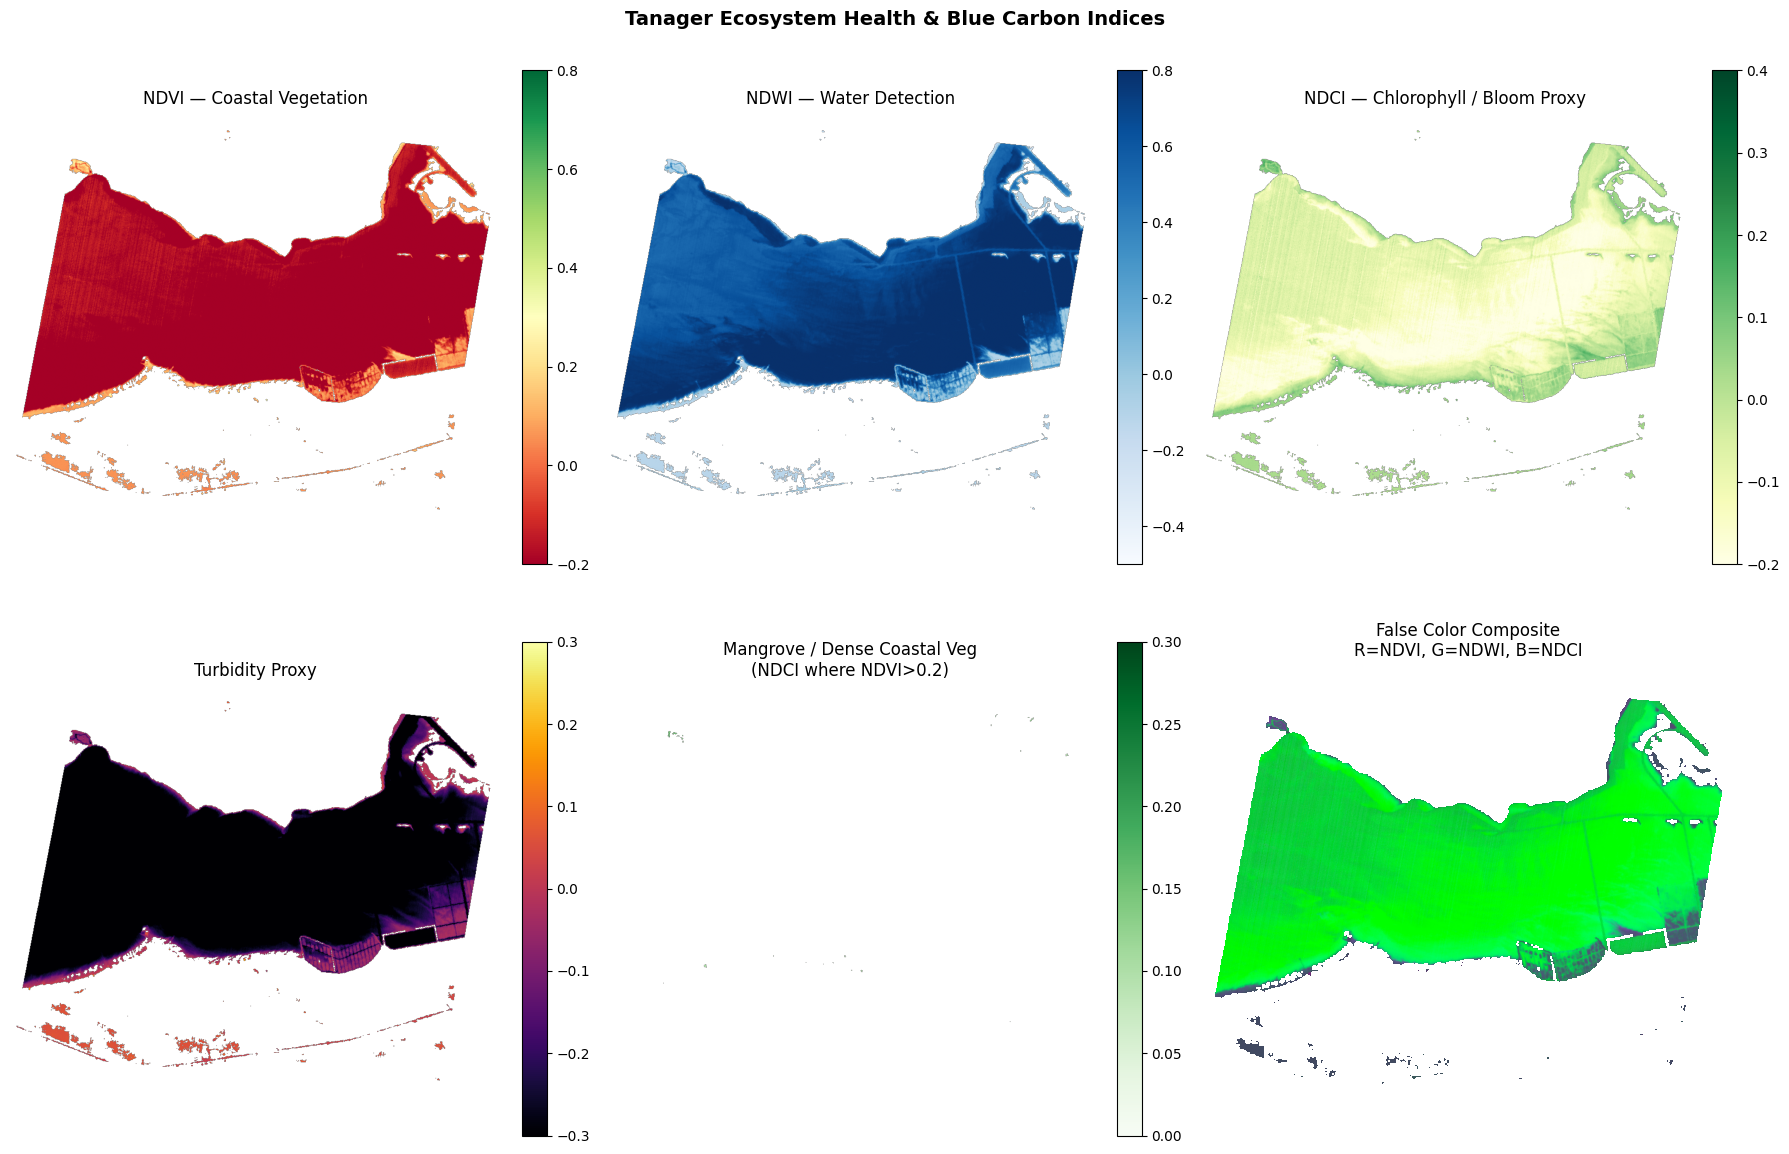

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

im1 = axes[0,0].imshow(NDVI, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[0,0].set_title("NDVI — Coastal Vegetation"); axes[0,0].axis("off")
plt.colorbar(im1, ax=axes[0,0], fraction=0.046, pad=0.04)

im2 = axes[0,1].imshow(NDWI, cmap="Blues", vmin=-0.5, vmax=0.8)
axes[0,1].set_title("NDWI — Water Detection"); axes[0,1].axis("off")
plt.colorbar(im2, ax=axes[0,1], fraction=0.046, pad=0.04)

im3 = axes[0,2].imshow(NDCI, cmap="YlGn", vmin=-0.2, vmax=0.4)
axes[0,2].set_title("NDCI — Chlorophyll / Bloom Proxy"); axes[0,2].axis("off")
plt.colorbar(im3, ax=axes[0,2], fraction=0.046, pad=0.04)

im4 = axes[1,0].imshow(Turbidity, cmap="inferno", vmin=-0.3, vmax=0.3)
axes[1,0].set_title("Turbidity Proxy"); axes[1,0].axis("off")
plt.colorbar(im4, ax=axes[1,0], fraction=0.046, pad=0.04)

im5 = axes[1,1].imshow(Mangrove_proxy, cmap="Greens", vmin=0, vmax=0.3)
axes[1,1].set_title("Mangrove / Dense Coastal Veg\n(NDCI where NDVI>0.2)"); axes[1,1].axis("off")
plt.colorbar(im5, ax=axes[1,1], fraction=0.046, pad=0.04)

# False-color composite: R=NDVI, G=NDWI, B=NDCI
rgb = np.stack([
    np.clip((NDVI + 0.2) / 1.0, 0, 1),
    np.clip((NDWI + 0.5) / 1.3, 0, 1),
    np.clip((NDCI + 0.2) / 0.6, 0, 1)
], axis=-1)
axes[1,2].imshow(rgb)
axes[1,2].set_title("False Color Composite\nR=NDVI, G=NDWI, B=NDCI"); axes[1,2].axis("off")

plt.suptitle("Tanager Ecosystem Health & Blue Carbon Indices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

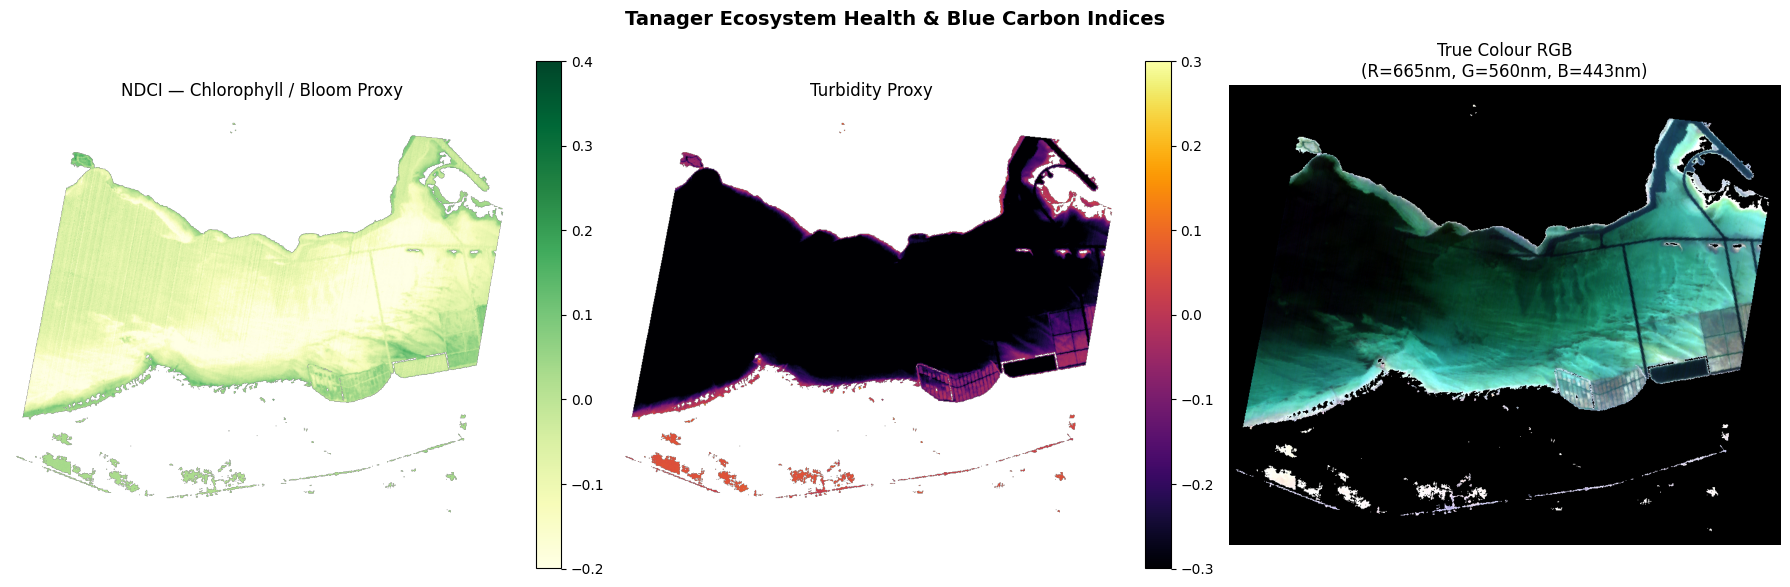

In [ ]:
# True RGB composite using Tanager surface reflectance bands
# R = 665 nm, G = 560 nm, B = 443 nm
# Percentile stretch so the image isn't washed out or too dark
def stretch(arr, p_low=2, p_high=98):
    lo, hi = np.nanpercentile(arr, p_low), np.nanpercentile(arr, p_high)
    return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)

rgb_true = np.stack([
    stretch(R_665),   # Red channel
    stretch(R_560),   # Green channel
    stretch(R_443),   # Blue channel
], axis=-1)
# Replace NaN pixels with 0 for display
rgb_true = np.nan_to_num(rgb_true, nan=0.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # was (18,12) — too tall for 1 row

im1 = axes[0].imshow(NDCI, cmap="YlGn", vmin=-0.2, vmax=0.4)
axes[0].set_title("NDCI — Chlorophyll / Bloom Proxy"); axes[0].axis("off")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)  # was im3 (wrong variable)

im2 = axes[1].imshow(Turbidity, cmap="inferno", vmin=-0.3, vmax=0.3)
axes[1].set_title("Turbidity Proxy"); axes[1].axis("off")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)  # was im4 (wrong variable)

axes[2].imshow(rgb_true)
axes[2].set_title("True Colour RGB\n(R=665nm, G=560nm, B=443nm)"); axes[2].axis("off")  # was axes[1,2] (wrong indexing for 1-row grid)

plt.suptitle("Tanager Ecosystem Health & Blue Carbon Indices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 11 – Summary Statistics


In [ ]:
def summarize(name, arr):
    valid_data = arr[~np.isnan(arr)]
    if len(valid_data) == 0:
        print(f"{name}: no valid data")
        return
    print(f"{name}: min={valid_data.min():.3f}  max={valid_data.max():.3f}  "
          f"mean={valid_data.mean():.3f}  std={valid_data.std():.3f}")

summarize("NDVI",      NDVI)
summarize("NDWI",      NDWI)
summarize("NDCI",      NDCI)
summarize("Turbidity", Turbidity)

NDVI: min=-0.676  max=0.393  mean=-0.306  std=0.192
NDWI: min=-0.367  max=0.874  mean=0.636  std=0.232
NDCI: min=-0.276  max=0.249  mean=-0.095  std=0.076
Turbidity: min=-0.605  max=0.184  mean=-0.379  std=0.152


## Step 12 – Mean Spectrum (Full Scene)

The spectral signature integrates all land cover types in the scene.
Look for the chlorophyll absorption dip at ~680 nm and the vegetation red-edge jump at ~720 nm.

We exclude the two water-vapor absorption troughs (1350–1450 nm, 1800–1950 nm) plus wavelengths beyond 2450 nm, where the SWIR2 detector's edge channels and the collapsing atmospheric window otherwise produce erratic reflectance spikes rather than real surface signal.

/tmp/ipykernel_1385/3858346063.py:23: RuntimeWarning: Mean of empty slice
  mean_spec = np.nanmean(cube, axis=(1,2))


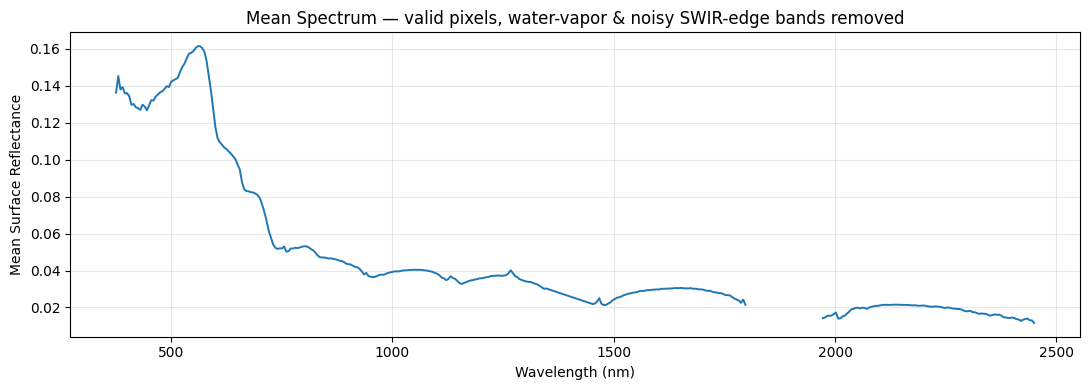

In [ ]:
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

# Beyond ~2450 nm we're at the edge of the SWIR2 detector array: solar
# irradiance and atmospheric transmission both collapse toward the edge of
# the SWIR atmospheric window, and edge channels have the sensor's worst
# signal-to-noise ratio. Reflectance = radiance / irradiance blows up into
# noise there rather than showing real surface signal, so we drop that tail
# the same way we drop the water-vapor troughs.
SWIR_EDGE_NM = 2450

def is_bad_band(wl):
    return is_water_vapor(wl) or wl > SWIR_EDGE_NM

stride = 8
with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_bad_band(w)]
    cube = sr[good_idx, ::stride, ::stride].astype("float32")
    mask = valid[::stride, ::stride]
    cube[:, ~mask] = np.nan
    cube[cube < 0] = np.nan
    mean_spec = np.nanmean(cube, axis=(1,2))

wls = [wavelengths_nm[i] for i in good_idx]
plt.figure(figsize=(11,4))
plt.plot(wls, mean_spec, lw=1.4)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Mean Spectrum — valid pixels, water-vapor & noisy SWIR-edge bands removed")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Spectral Signature of the Highest-Value Pixel per Index

The plot above shows the **scene-average** spectrum. Now let's look at individual pixels: for each index (NDVI, NDWI, NDCI, Turbidity), we find the single pixel with the *highest* value — e.g. the densest coastal vegetation (NDVI), the clearest open water (NDWI), the strongest chlorophyll/algal-bloom signal (NDCI), and the most sediment-laden water (Turbidity) — and plot its full spectral signature (water-vapor bands removed). Comparing these extreme-pixel spectra side by side shows how differently these land-cover conditions reflect light across the spectrum.

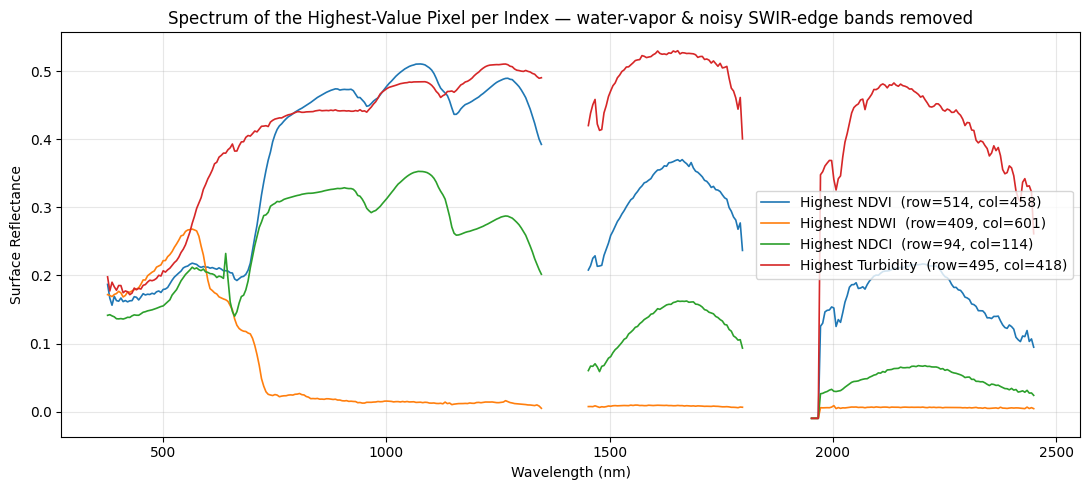

In [ ]:
# For the pixel with the single highest value of each index, read and plot its
# full spectral signature (reusing `good_idx`/`wls` from the cell above, which
# already exclude the water-vapor troughs and the noisy SWIR-edge tail).
#
# `good_idx` skips the excluded bands, so plain plt.plot(wls, ...) would draw
# a straight connecting line across those gaps. with_gaps() inserts a NaN
# wherever good_idx jumps by more than 1, so the line actually breaks there.
def with_gaps(band_idx, x, y):
    x_out, y_out = [x[0]], [y[0]]
    for k in range(1, len(band_idx)):
        if band_idx[k] != band_idx[k - 1] + 1:
            x_out.append((x[k - 1] + x[k]) / 2)
            y_out.append(np.nan)
        x_out.append(x[k]); y_out.append(y[k])
    return x_out, y_out

indices = {"NDVI": NDVI, "NDWI": NDWI, "NDCI": NDCI, "Turbidity": Turbidity}

plt.figure(figsize=(11, 5))
with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    for name, arr in indices.items():
        row, col = np.unravel_index(np.nanargmax(arr), arr.shape)
        pixel_spec = sr[good_idx, row, col].astype("float32")
        x_plot, y_plot = with_gaps(good_idx, wls, pixel_spec)
        plt.plot(x_plot, y_plot, lw=1.2, label=f"Highest {name}  (row={row}, col={col})")

plt.xlabel("Wavelength (nm)"); plt.ylabel("Surface Reflectance")
plt.title("Spectrum of the Highest-Value Pixel per Index — water-vapor & noisy SWIR-edge bands removed")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 13 – Water vs Vegetation Spectral Comparison

Compare the average spectrum of water pixels (NDWI > 0.1) vs vegetation pixels (NDVI > 0.3).


/tmp/ipykernel_1385/229170325.py:29: RuntimeWarning: Mean of empty slice
  return [float(np.nanmean(cube[j])) for j in range(len(good_idx))]


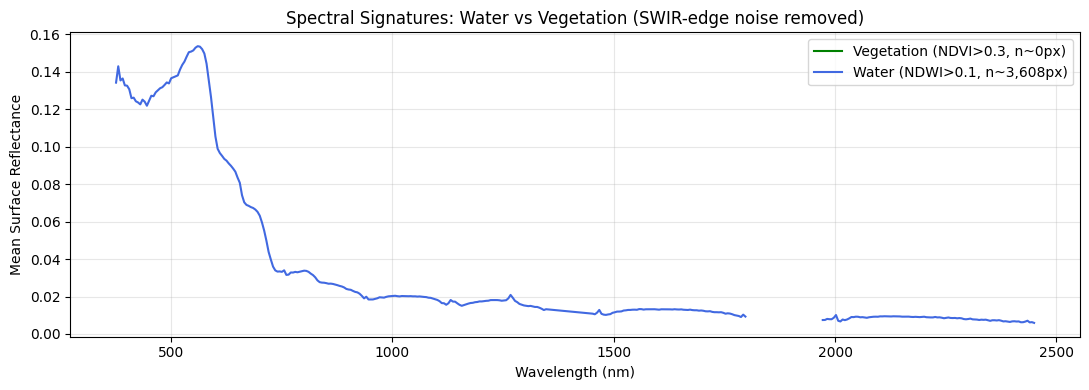

In [ ]:
stride = 8
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

# Beyond ~2450 nm we're at the edge of the SWIR2 detector array: solar
# irradiance and atmospheric transmission both collapse toward the edge of
# the SWIR atmospheric window, and edge channels have the sensor's worst
# signal-to-noise ratio. Reflectance = radiance / irradiance blows up into
# noise there rather than showing real surface signal, so we drop that tail
# the same way we drop the water-vapor troughs.
SWIR_EDGE_NM = 2450

def is_bad_band(wl):
    return is_water_vapor(wl) or wl > SWIR_EDGE_NM

good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_bad_band(w)]
wls = [wavelengths_nm[i] for i in good_idx]

water_mask = (NDWI > 0.1) & valid
veg_mask   = (NDVI > 0.3) & valid

def mean_spec(mask):
    with h5py.File(local_path, "r") as f:
        sr = f[f"{root}/surface_reflectance"]
        cube = sr[good_idx, ::stride, ::stride].astype("float32")
    m = mask[::stride, ::stride]
    cube[:, ~m] = np.nan
    cube[cube < 0] = np.nan
    return [float(np.nanmean(cube[j])) for j in range(len(good_idx))]

spec_water = mean_spec(water_mask)
spec_veg   = mean_spec(veg_mask)

plt.figure(figsize=(11, 4))
plt.plot(wls, spec_veg,   color="green",  lw=1.5, label=f"Vegetation (NDVI>0.3, n~{veg_mask.sum()//stride**2:,}px)")
plt.plot(wls, spec_water, color="royalblue", lw=1.5, label=f"Water (NDWI>0.1, n~{water_mask.sum()//stride**2:,}px)")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Spectral Signatures: Water vs Vegetation (SWIR-edge noise removed)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 🚀 Hackathon Challenge Ideas

- **Mangrove area estimation** — threshold the Mangrove_proxy map and compute area in km²
- **Algal bloom detection** — find pixels where NDCI > 0.2 within NDWI-positive water bodies
- **Seagrass mapping** — shallow water with positive NDVI signature
- **Carbon stock estimation** — combine mangrove extent with published carbon density values (t C/ha)
- **Turbidity monitoring** — track sediment plumes from rivers or coastal construction

### 📊 Before You Submit: Think Like a Product, Not Just a Model

A working technical demo is only half of a hackathon submission. Before you submit your Proof of Concept, make sure you can also answer:

- **What real business problem does this solve, and for whom?** Who has this problem today, and what do they currently do about it without your solution?
- **How good is your model, really?** Include concrete validation statistics for your PoC — accuracy, precision/recall, RMSE, IoU, or a comparison against ground truth/known events — not just "it looks right on the map."
- **How will end users actually see your results?** You don't need to build a full frontend for the PoC, but you should be able to describe how your application would deliver value in practice — e.g. a dashboard, a REST API, an alerting/notification system, a scheduled report — and roughly what that would look like.

---

> 📖 Created by: [LInkedin: Dr. Vincent Markiet - Space42](https://www.linkedin.com/in/vincentmarkiet/)

> 📖 Data license: CC-BY-4.0 © Planet Labs PBC


In [ ]:
item = [it for it in items if it["id"] == "20250511_074311_00_4001"][0]
print(item["id"], item["properties"]["datetime"][:10])

NameError: name 'items' is not defined

In [ ]:
sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
local_path = os.path.baseame(sr_url)
r = requests.get(sr_url, stream=True)
r.raise_for_status()
fout = open(local_path, "wb")
for chunk in r.iter_content(chunk_size=1024*1024): fout.write(chunk)
fout.close()
print("Ready:", local_path)

In [ ]:
import os, requests, h5py, numpy as np
item_id = "20250511_074311_00_4001"
url = "https://www.planet.com/data/stac/tanager-core-imagery/coastal-water-bodies/" + item_id + "/" + item_id + ".json"
item = requests.get(url, timeout=60).json()
sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
local_path = os.path.basename(sr_url)
print("File exists:", os.path.exists(local_path))

In [ ]:
r = requests.get(sr_url, stream=True)
r.raise_for_status()
fout = open(local_path, "wb")
for chunk in r.iter_content(chunk_size=1024*1024): fout.write(chunk)
fout.close()
print("Ready:", local_path)

In [ ]:
land = NDWI < 0
print("Land pixels:", int(np.nansum(land)))
print("NDVI > 0.0 :", int(np.nansum(land & (NDVI > 0.0))))
print("NDVI > 0.05:", int(np.nansum(land & (NDVI > 0.05))))
print("NDVI > 0.1 :", int(np.nansum(land & (NDVI > 0.1))))
print("NDVI > 0.15:", int(np.nansum(land & (NDVI > 0.15))))
print("NDVI > 0.2 :", int(np.nansum(land & (NDVI > 0.2))))
print("NDVI pct 50/90/99 on land:", np.round(np.nanpercentile(NDVI[land], [50, 90, 99]), 3))

Land pixels: 14357
NDVI > 0.0 : 14357
NDVI > 0.05: 12656
NDVI > 0.1 : 2933
NDVI > 0.15: 714
NDVI > 0.2 : 166
NDVI pct 50/90/99 on land: [0.066 0.126 0.204]


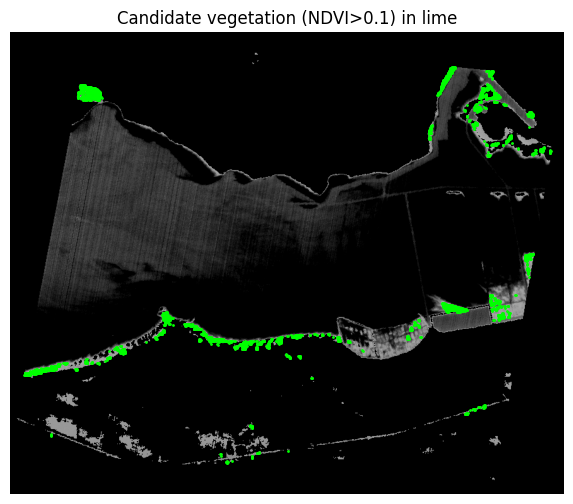

In [ ]:
cand = land & (NDVI > 0.1)
plt.figure(figsize=(10, 6))
plt.imshow(np.nan_to_num(NDVI, nan=-0.3), cmap="gray", vmin=-0.3, vmax=0.3)
ys, xs = np.where(cand)
plt.scatter(xs, ys, s=1, c="lime")
plt.title("Candidate vegetation (NDVI>0.1) in lime")
plt.axis("off")
plt.show()

In [ ]:
from scipy import ndimage
lab, n = ndimage.label(cand)
sizes = ndimage.sum(cand, lab, range(1, n + 1))
print("Patches:", n)
print("Largest 5 (pixels):", np.sort(sizes)[::-1][:5])
print("Total candidate pixels:", int(cand.sum()))
print("Approx area km2 (30 m pixel):", round(cand.sum() * 900 / 1e6, 2))

Patches: 238
Largest 5 (pixels): [264. 189. 179. 159. 133.]
Total candidate pixels: 2933
Approx area km2 (30 m pixel): 2.64


In [ ]:
print("Pixel size info:", item["properties"].get("gsd"))
pix = float(item["properties"].get("gsd", 30))
area_km2 = sizes * pix * pix / 1e6
meanNDVI = ndimage.mean(NDVI, lab, range(1, n + 1))
cy = ndimage.center_of_mass(cand, lab, range(1, n + 1))
import pandas as pd
df = pd.DataFrame({"patch": range(1, n + 1), "pixels": sizes, "area_km2": area_km2, "mean_ndvi": meanNDVI, "row": [c[0] for c in cy], "col": [c[1] for c in cy]})
df["size_rank"] = df["pixels"].rank(pct=True)
df["health_rank"] = 1 - df["mean_ndvi"].rank(pct=True)
df["priority"] = 0.5 * df["size_rank"] + 0.5 * df["health_rank"]
df = df.sort_values("priority", ascending=False)
os.makedirs("results", exist_ok=True)
df.to_csv("results/priority_sites.csv", index=False)
print(df.head(10))
print("Total area km2:", round(area_km2.sum(), 2))

Pixel size info: 34.78
     patch  pixels  area_km2  mean_ndvi         row         col  size_rank  \
122    123    48.0  0.058063   0.107233  451.479167  778.104167   0.953782   
70      71     8.0  0.009677   0.103053  177.875000  765.000000   0.731092   
60      61     8.0  0.009677   0.103211  148.875000  735.125000   0.731092   
213    214    76.0  0.091933   0.108641  531.947368   69.236842   0.970588   
135    136     8.0  0.009677   0.103307  466.625000  648.125000   0.731092   
73      74    29.0  0.035080   0.107308  186.310345  843.344828   0.901261   
78      79     5.0  0.006048   0.102193  191.200000  833.000000   0.653361   
64      65     7.0  0.008468   0.103407  167.857143  665.428571   0.703782   
63      64    31.0  0.037499   0.108372  168.161290  791.322581   0.913866   
79      80     5.0  0.006048   0.102883  193.000000  828.400000   0.653361   

     health_rank  priority  
122     0.668067  0.810924  
70      0.861345  0.796218  
60      0.848739  0.789916  
21

In [ ]:
bb = item["bbox"]
H, W = NDVI.shape
df["lon"] = bb[0] + (df["col"] / W) * (bb[2] - bb[0])
df["lat"] = bb[3] - (df["row"] / H) * (bb[3] - bb[1])
df.to_csv("results/priority_sites.csv", index=False)
print(df[["patch", "area_km2", "priority", "lon", "lat"]].head(5))

     patch  area_km2  priority        lon        lat
122    123  0.058063  0.810924  53.864447  24.067718
70      71  0.009677  0.796218  53.860533  24.143053
60      61  0.009677  0.789916  53.851608  24.151038
213    214  0.091933  0.787815  53.652690  24.045562
135    136  0.009677  0.785714  53.825619  24.063548


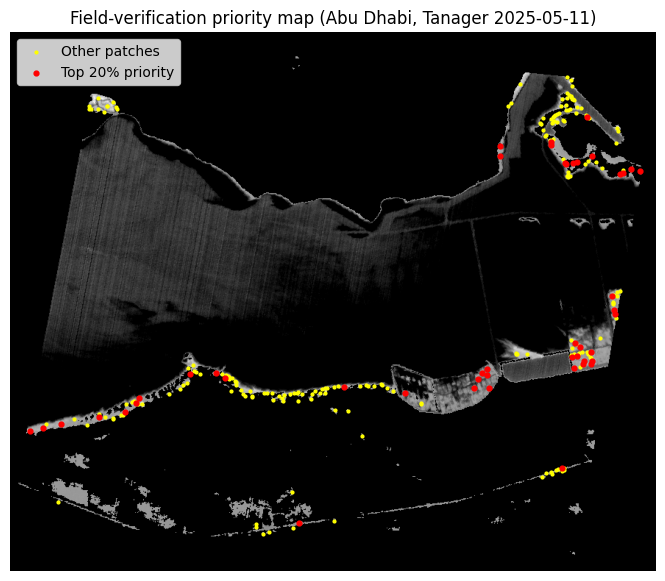

Top 20% patches: 47 of 238


In [ ]:
top = df.head(int(len(df) * 0.2))
plt.figure(figsize=(10, 7))
plt.imshow(np.nan_to_num(NDVI, nan=-0.3), cmap="gray", vmin=-0.3, vmax=0.3)
plt.scatter(df["col"], df["row"], s=4, c="yellow", label="Other patches")
plt.scatter(top["col"], top["row"], s=12, c="red", label="Top 20% priority")
plt.legend()
plt.title("Field-verification priority map (Abu Dhabi, Tanager 2025-05-11)")
plt.axis("off")
plt.savefig("results/priority_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Top 20% patches:", len(top), "of", len(df))

In [ ]:
%pip install pystac-client planetary-computer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.5 MB/s eta 0:00:00


In [ ]:
import pystac_client, planetary_computer
cat = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)
bb = item["bbox"]
res = cat.search(collections=["esa-worldcover"], bbox=bb).item_collection()
print("WorldCover items found:", len(res))
for it in res: print(it.id, list(it.assets.keys()))

WorldCover items found: 4
ESA_WorldCover_10m_2021_v200_N24E051 ['map', 'input_quality', 'tilejson', 'rendered_preview']
ESA_WorldCover_10m_2021_v200_N21E051 ['map', 'input_quality', 'tilejson', 'rendered_preview']
ESA_WorldCover_10m_2020_v100_N24E051 ['map', 'input_quality', 'tilejson', 'rendered_preview']
ESA_WorldCover_10m_2020_v100_N21E051 ['map', 'input_quality', 'tilejson', 'rendered_preview']


In [ ]:
import rioxarray
from rasterio.enums import Resampling
t = [i for i in res if "2021" in i.id and "N24E051" in i.id][0]
da = rioxarray.open_rasterio(t.assets["map"].href).squeeze()
da = da.rio.clip_box(bb[0], bb[1], bb[2], bb[3])
print("WorldCover shape:", da.shape)
print("Mangrove (95) pixels:", int((da.values == 95).sum()))

In [ ]:
%pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
print("item" in globals(), "NDVI" in globals(), "df" in globals(), "res" in globals())
print(os.path.exists("results/priority_sites.csv"))

In [ ]:
%pip install -q pystac-client planetary-computer rioxarray h5py scipy pandas matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.3 MB/s eta 0:00:00


In [ ]:
import os, requests, h5py, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import ndimage
os.makedirs("results", exist_ok=True)
iid = "20250511_074311_00_4001"
item = requests.get("https://www.planet.com/data/stac/tanager-core-imagery/coastal-water-bodies/" + iid + "/" + iid + ".json", timeout=60).json()
sr_key = "ortho_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
local_path = os.path.basename(sr_url)
print("File exists:", os.path.exists(local_path))

File exists: False


In [ ]:
r = requests.get(sr_url, stream=True)
r.raise_for_status()
fout = open(local_path, "wb")
for chunk in r.iter_content(chunk_size=1024*1024): fout.write(chunk)
fout.close()
print("Ready:", local_path)

Ready: 20250511_074311_00_4001_ortho_sr_hdf5.h5


In [ ]:
root = "HDFEOS/GRIDS/HYP/Data Fields"
f = h5py.File(local_path, "r")
valid = (f[root + "/nodata_pixels"][:] == 0) & (f[root + "/beta_cloud_mask"][:] == 0) & (f[root + "/beta_cirrus_mask"][:] == 0)
sb = [b for b in item["assets"][sr_key]["bands"] if "eo:center_wavelength" in b]
wl = np.array([b["eo:center_wavelength"] for b in sb], dtype=float) * 1000.0
sr = f[root + "/surface_reflectance"]
R560 = sr[int(np.argmin(np.abs(wl - 560))), :, :].astype("float32")
R665 = sr[int(np.argmin(np.abs(wl - 665))), :, :].astype("float32")
R800 = sr[int(np.argmin(np.abs(wl - 800))), :, :].astype("float32")
R860 = sr[int(np.argmin(np.abs(wl - 860))), :, :].astype("float32")
for a in [R560, R665, R800, R860]: a[~valid] = np.nan
NDVI = (R800 - R665) / (R800 + R665 + 1e-6)
NDWI = (R560 - R860) / (R560 + R860 + 1e-6)
cand = (NDWI < 0) & (NDVI > 0.1)
lab, n = ndimage.label(cand)
sizes = ndimage.sum(cand, lab, range(1, n + 1))
print("Patches:", n, "| pixels:", int(cand.sum()))

Patches: 238 | pixels: 2933


In [ ]:
%pip install -q pystac-client planetary-computer rioxarray

In [ ]:
import pystac_client, planetary_computer, rioxarray
bb = item["bbox"]
cat = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)
res = cat.search(collections=["esa-worldcover"], bbox=bb).item_collection()
t = [i for i in res if "2021" in i.id][0]
da = rioxarray.open_rasterio(t.assets["map"].href).squeeze()
da = da.rio.clip_box(bb[0], bb[1], bb[2], bb[3])
print("Tile used:", t.id)
print("WorldCover shape:", da.shape)
print("Mangrove (95) pixels:", int((da.values == 95).sum()))

Tile used: ESA_WorldCover_10m_2021_v200_N24E051
WorldCover shape: (2305, 3148)
Mangrove (95) pixels: 0


In [ ]:
H, W = NDVI.shape
rows, cols = np.where(cand)
lon = bb[0] + (cols / W) * (bb[2] - bb[0])
lat = bb[3] - (rows / H) * (bb[3] - bb[1])
xs = da.x.values
ys = da.y.values
ix = np.clip(np.searchsorted(xs, lon), 0, len(xs) - 1)
iy = np.clip(len(ys) - 1 - np.searchsorted(ys[::-1], lat), 0, len(ys) - 1)
cls = da.values[iy, ix]
print(pd.Series(cls).value_counts())

80    1780
60    1086
50      52
20       9
30       3
10       2
40       1
Name: count, dtype: int64


In [ ]:
cand2 = (NDWI < 0) & (NDVI > 0.15)
r2, c2 = np.where(cand2)
lon2 = bb[0] + (c2 / W) * (bb[2] - bb[0])
lat2 = bb[3] - (r2 / H) * (bb[3] - bb[1])
ix2 = np.clip(np.searchsorted(xs, lon2), 0, len(xs) - 1)
iy2 = np.clip(len(ys) - 1 - np.searchsorted(ys[::-1], lat2), 0, len(ys) - 1)
print(pd.Series(da.values[iy2, ix2]).value_counts())

80    407
60    290
50     16
10      1
Name: count, dtype: int64


238 patches | total km2: 3.55


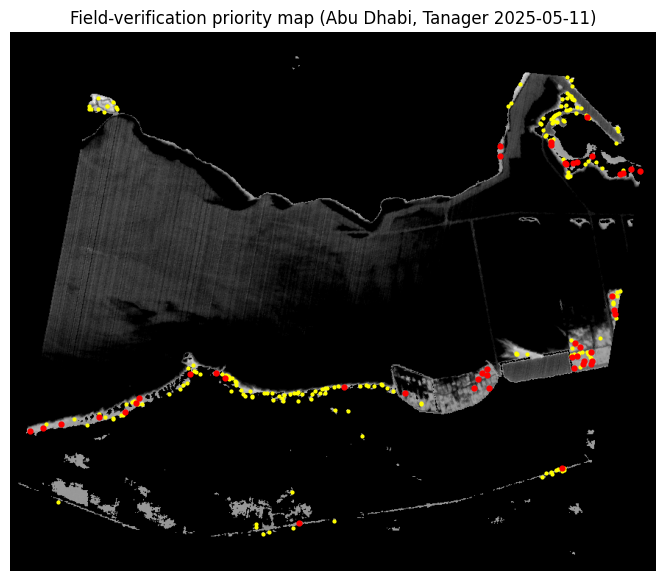

In [ ]:
H, W = NDVI.shape
rr, cc = np.where(cand)
df = pd.DataFrame({"patch": lab[rr, cc], "row": rr, "col": cc})
g = df.groupby("patch").agg(pixels=("row", "size"), row=("row", "mean"), col=("col", "mean")).reset_index()
g["mean_ndvi"] = ndimage.mean(NDVI, lab, g["patch"].values)
g["area_km2"] = g["pixels"] * 34.78 * 34.78 / 1e6
g["lon"] = bb[0] + (g["col"] / W) * (bb[2] - bb[0])
g["lat"] = bb[3] - (g["row"] / H) * (bb[3] - bb[1])
g["priority"] = 0.5 * g["pixels"].rank(pct=True) + 0.5 * (1 - g["mean_ndvi"].rank(pct=True))
g = g.sort_values("priority", ascending=False)
g.to_csv("results/priority_sites.csv", index=False)
top = g.head(int(len(g) * 0.2))
plt.figure(figsize=(10, 7))
plt.imshow(np.nan_to_num(NDVI, nan=-0.3), cmap="gray", vmin=-0.3, vmax=0.3)
plt.scatter(g["col"], g["row"], s=4, c="yellow")
plt.scatter(top["col"], top["row"], s=12, c="red")
plt.title("Field-verification priority map (Abu Dhabi, Tanager 2025-05-11)")
plt.axis("off")
plt.savefig("results/priority_map.png", dpi=150, bbox_inches="tight")
print(len(g), "patches | total km2:", round(g["area_km2"].sum(), 2))

In [ ]:
import requests
base = "https://www.planet.com/data/stac/tanager-core-imagery/coastal-water-bodies/"
col = requests.get(base + "collection.json", timeout=60).json()
ids = [l["href"].split("/")[-1][:-5] for l in col["links"] if l["rel"] == "item"]
its = [requests.get(base + i + "/" + i + ".json", timeout=60).json() for i in ids]
eg = [(x["id"], x["properties"]["datetime"][:10], x["properties"].get("eo:cloud_cover"), x["bbox"]) for x in its if 33 < x["bbox"][0] < 35 and 27 < x["bbox"][1] < 28]
for e in eg: print(e)

In [ ]:
!pip install pystac-client planetary-computer stackstac matplotlib rasterio -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 610.7 kB/s eta 0:00:00


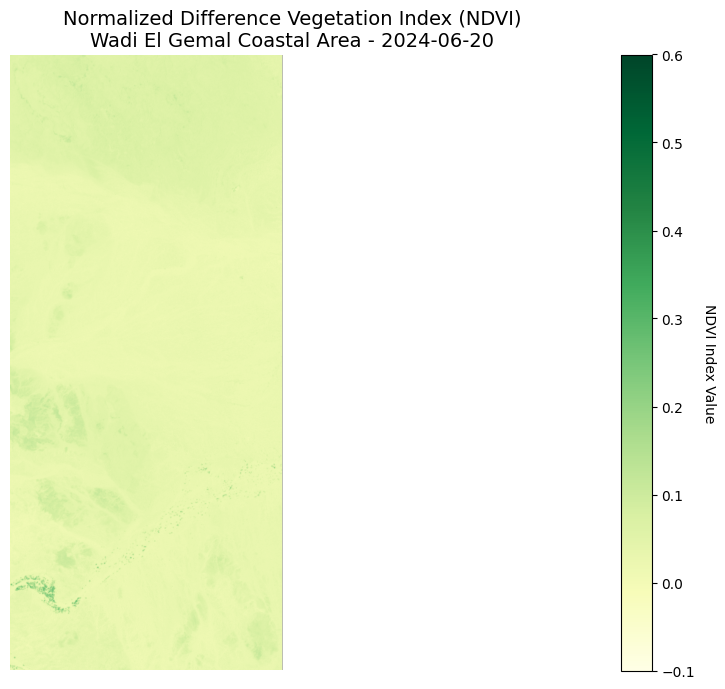

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pystac_client
import planetary_computer as pc
import stackstac

bbox = [35.03, 24.63, 35.12, 24.72]

catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace)

search = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime="2024-01-01/2024-06-30", query={"eo:cloud_cover": {"lt": 5}})

items = search.item_collection()
selected_item = items[0]

data = stackstac.stack([selected_item], assets=["B04", "B08"], bounds_latlon=bbox, epsg=32636, resolution=10)

data_computed = data.compute()

red = data_computed.sel(band="B04").values[0].astype(float)
nir = data_computed.sel(band="B08").values[0].astype(float)

ndvi = np.where((nir + red) == 0, 0, (nir - red) / (nir + red))

plt.figure(figsize=(12, 8))
plt.imshow(ndvi, cmap="YlGn", vmin=-0.1, vmax=0.6)

cbar = plt.colorbar()
cbar.set_label("NDVI Index Value", rotation=270, labelpad=15)

acquisition_date = selected_item.datetime.strftime("%Y-%m-%d")
plt.title(f"Normalized Difference Vegetation Index (NDVI)\nWadi El Gemal Coastal Area - {acquisition_date}", fontsize=14)
plt.axis("off")

plt.savefig("example_output.png", bbox_inches="tight", dpi=300)
plt.show()
